<a href="https://colab.research.google.com/github/azholl/lis5693/blob/main/lab-4/lab_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install sklearn

  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.


I followed an old stack overflow comment's instructions to use Excel to change the dataset file format to a CSV to get this code to work, as the original file format was not CSV.

In [5]:
import requests
import io

url = "https://raw.githubusercontent.com/azholl/lis5693/main/lab-4/SMSSpamCollection.csv"
response = requests.get(url)
response.raise_for_status()
text = response.text

In [6]:
import pandas as pd

df = pd.read_csv(io.StringIO(text))
print(df.head())

  Column1                                            Column2
0     ham  Go until jurong point, crazy.. Available only ...
1     ham                      Ok lar... Joking wif u oni...
2    spam  Free entry in 2 a wkly comp to win FA Cup fina...
3     ham  U dun say so early hor... U c already then say...
4     ham  Nah I don't think he goes to usf, he lives aro...


Excel automatically named the columns in the dataset Column1 and Column2, so I'm using this code to change the names of those columns to what data they actually represent.

In [8]:
df.columns = ['label', 'message']
print(df.head())

  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...


Splitting data into features and target labels. The two columns in the dataset are the label column, which is indicating whether the message that follows is spam or ham, and the message column that contains the actual message itself. I used the message column as the feature because it contains the text data that the model will be analyzing to learn patterns that are associated with either spam or non-spam messages. I used the label column as the target because it is the category the classifier will be attempting to predict.

In [9]:
features = df['message']
target = df['label']

In [15]:
target_names = ['ham','spam']

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.pipeline import Pipeline

# split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.3, random_state=42)

# Show the results of the split
print("Training set has {} samples.".format(X_train.shape[0]))
print("Testing set has {} samples.".format(X_test.shape[0]))

# Remove or replace NaN values in X_train and X_test
X_train = X_train.fillna('')
X_test = X_test.fillna('')

preprocessing = Pipeline([
    ('vect', CountVectorizer()),
    ('tfidf', TfidfTransformer())
])

print("Preprocessing training data...")
train_preprocessed = preprocessing.fit_transform(X_train)

print("Preprocessing test data...")
test_preprocessed = preprocessing.transform(X_test)

Training set has 3901 samples.
Testing set has 1673 samples.
Preprocessing training data...
Preprocessing test data...


In [11]:
y_test.unique()

array(['ham', 'spam'], dtype=object)

In [12]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

nb_classifier = MultinomialNB()
svm_classifier = LinearSVC()
lr_classifier = LogisticRegression(multi_class="ovr")

print("Training Naive Bayes classifier...")
nb_classifier.fit(train_preprocessed, y_train)

print("Training SVM classifier...")
svm_classifier.fit(train_preprocessed, y_train)

print("Training Logistic Regression classifier...")
lr_classifier.fit(train_preprocessed, y_train)

Training Naive Bayes classifier...
Training SVM classifier...
Training Logistic Regression classifier...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(multi_class='ovr')

In [13]:
nb_predictions = nb_classifier.predict(test_preprocessed)
svm_predictions = svm_classifier.predict(test_preprocessed)
lr_predictions = lr_classifier.predict(test_preprocessed)

In [14]:
import numpy as np

print("NB Accuracy:", np.mean(nb_predictions == y_test))
print("SVM Accuracy:", np.mean(svm_predictions == y_test))
print("LR Accuracy:", np.mean(lr_predictions == y_test))

NB Accuracy: 0.9599521817095039
SVM Accuracy: 0.986252241482367
LR Accuracy: 0.9707112970711297


Running classification reports

In [17]:
from sklearn.metrics import classification_report  # Import classification_report

print(classification_report(y_test, nb_predictions, target_names=target_names))
print(classification_report(y_test, svm_predictions, target_names=target_names))
print(classification_report(y_test, lr_predictions, target_names=target_names))

              precision    recall  f1-score   support

         ham       0.96      1.00      0.98      1447
        spam       1.00      0.70      0.83       226

    accuracy                           0.96      1673
   macro avg       0.98      0.85      0.90      1673
weighted avg       0.96      0.96      0.96      1673

              precision    recall  f1-score   support

         ham       0.99      1.00      0.99      1447
        spam       0.97      0.92      0.95       226

    accuracy                           0.99      1673
   macro avg       0.98      0.96      0.97      1673
weighted avg       0.99      0.99      0.99      1673

              precision    recall  f1-score   support

         ham       0.97      1.00      0.98      1447
        spam       0.99      0.79      0.88       226

    accuracy                           0.97      1673
   macro avg       0.98      0.90      0.93      1673
weighted avg       0.97      0.97      0.97      1673



The Naive Bayes model had an accuracy of 0.96, but its recall for spam messages was low at 0.70, which means that it failed to correctly identify many spam messages. The LR model performed slightly better with an accuracy of 0.97 and a spam recall of 0.79.

The SVM model performed the best overall. It had the highest accuracy at 0.99 and strong performance across all evaluation metrics. Specifically, it had a spam recall of 0.92 and a spam precision of 0.97, meaning that it correctly identified most spam messages while also avoiding false spam message classifications.

(array([0.5, 1.5]), [Text(0.5, 0, 'ham'), Text(1.5, 0, 'spam')])

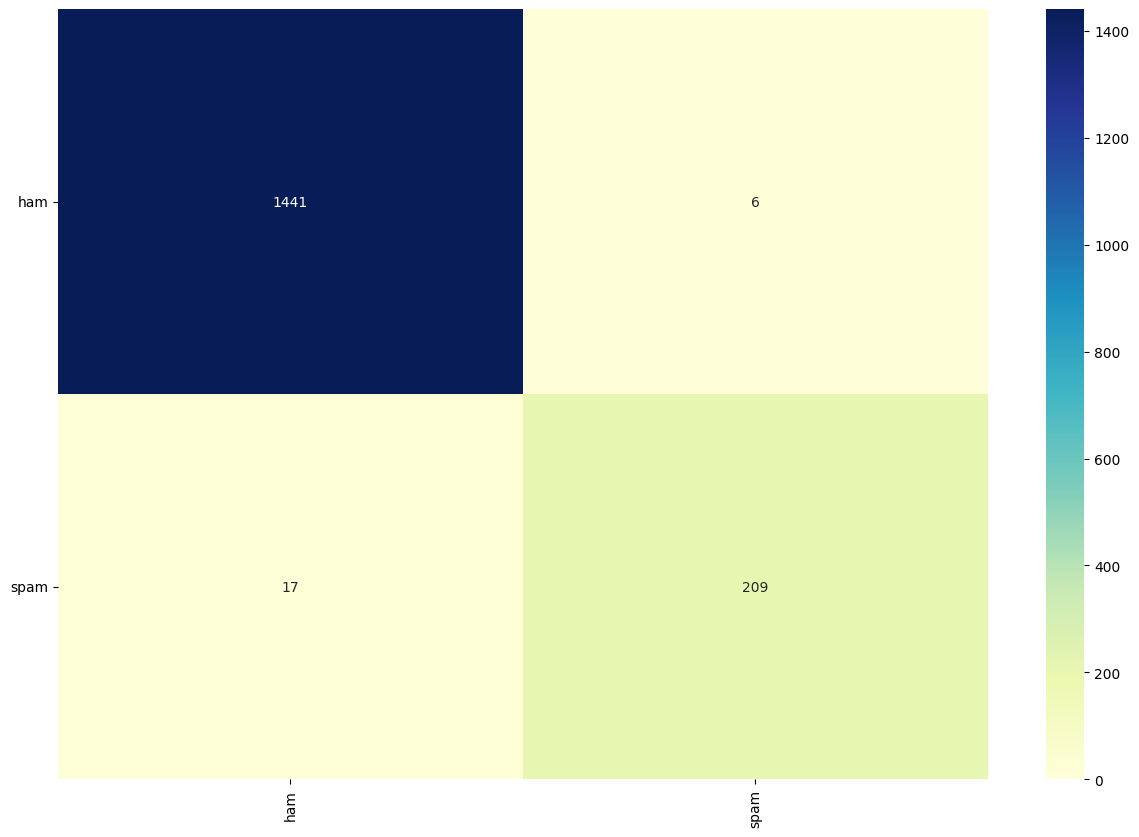

In [19]:
%matplotlib inline
from sklearn.metrics import confusion_matrix
import pandas as pd
import seaborn as sn
import matplotlib.pyplot as plt

conf_matrix = confusion_matrix(y_test, svm_predictions)
conf_matrix_df = pd.DataFrame(conf_matrix, index=target_names, columns=target_names)

plt.figure(figsize=(15, 10))
x = sn.heatmap(conf_matrix_df, annot=True, vmin=0, vmax=conf_matrix.max(), fmt='d', cmap="YlGnBu")
plt.yticks(rotation=0)
plt.xticks(rotation=90)

The top left value (1445) represents ham messages that were correctly classified, while the bottom right value (179) represents spam messages that were correctly classified. The other two values represent misclassifications. Two ham messages were incorrectly labeled as spam, and 47 spam messages were incorrectly labeled as ham.

**Supervised Machine Learning**

Uploading new data with an empty "label" column.

In [21]:
url = "https://raw.githubusercontent.com/azholl/lis5693/refs/heads/main/lab-4/new_data.csv"
response = requests.get(url)
response.raise_for_status() # Raise an exception for HTTP errors
raw_csv_data = response.text # Store the raw CSV string

new_data = pd.read_csv(io.StringIO(raw_csv_data))
print(new_data.head())

   label                                            message
0    NaN       Hey, are we still meeting after class today?
1    NaN  Congratulations! You have been selected for a ...
2    NaN  Can you send me the notes from yesterday's lec...
3    NaN  URGENT! Your account has been suspended. Verif...
4    NaN  Don't forget to bring your laptop to the libra...


In [22]:
text = new_data['message']
text

,message
0,"Hey, are we still meeting after class today?"
1,Congratulations! You have been selected for a ...
2,Can you send me the notes from yesterday's lec...
3,URGENT! Your account has been suspended. Verif...
4,Don't forget to bring your laptop to the libra...
...,...
103,You have unlocked a special mobile reward.
104,Can you send me the citation format again?
105,Redeem your exclusive offer now before it is g...
106,I'll check the dataset and message you back.


Text-preprocessing

In [23]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer

In [24]:
vect = TfidfVectorizer(stop_words = 'english').fit(X_train)
dtm = vect.fit_transform(X_train)

**Predicting Features: Fitting new dataset**

In [25]:
from sklearn.svm import LinearSVC
model = LinearSVC()
classif = model.fit(dtm, y_train)

Preprocesses the 'message' column from the new_data dataframe so that it's in the same format as the data the model was trained on.

In [26]:
test_dtm = vect.transform(new_data['message'])

In [27]:
import pandas as pd

# Removing any empty values for message
new_data['message'] = new_data['message'].fillna('')
test_dtm = vect.transform(new_data['message'])

Making predictions using the MLM for the 'predicted_label' in the new dataset.

In [28]:
test = classif.predict(test_dtm)

Renaming column from 0 to predicted_label

In [29]:
df2 = pd.DataFrame(test)
df2.rename(columns={0: 'predicted_label'}, inplace=True)

df2

,predicted_label
0,ham
1,spam
2,ham
3,spam
4,ham
...,...
103,spam
104,ham
105,ham
106,ham


Merge metadata from new_data file with the predicted_label column from df2 into the original file that contains the empty column, constructing the complete dataset.

In [30]:
new_data['predicted_label'] = df2['predicted_label']
combined_df = new_data

In [31]:
display(combined_df.head())

,label,message,predicted_label
0,NaN,"Hey, are we still meeting after class today?",ham
1,NaN,Congratulations! You have been selected for a ...,spam
2,NaN,Can you send me the notes from yesterday's lec...,ham
3,NaN,URGENT! Your account has been suspended. Verif...,spam
4,NaN,Don't forget to bring your laptop to the libra...,ham


In [33]:
combined_df.to_csv("predicted.csv", index=False)

In [34]:
from google.colab import files
files.download("predicted.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**What was classified correctly or misclassified**

Out of the 10 messages that I reviewed, 9 looked to be classified correctly, with one misclassification. The messages that had clear promotional spam language were identified as spam, and regular messages were identified as ham, except for one message about a "limited time offer free vacation package" being classified as ham even though it is spam. When the model was used on the original dataset, it didn't have a perfect 1 on any of the evaluation methods, it was in the upper .90s, so a 90% correct classification is about what I would expect from a new dataset. Overall the model is able to distinguish between typical spam patterns and regular messages well.

**Reflection**

For never having done this kind of work, I think that the lab went relatively well. I feel like I was able to grasp the concepts as I went through the steps, even though it was overwhelming at first and took longer than I expected. The main challenge I ran into was figuring out how to get the initial dataset file format converted to a CSV, as this is something I've never needed to do before, although it was very simple once I found the right thread describing how to do it. I took data analytics last semester, and the output of the classifiers looked familiar to something I would have seen in that class. The confusion matrix was also easy to interpret. Overall, I think this lab went well for me, and I am grateful the instructions that I was following were so clear and easy to understand for someone who doesn't have a background in Python.